Deliverabel 1

Viktor M.L hedman og Adrian N. Vangen

Importent imports

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import requests



Colekting the metrolagical data for 2025

In [ ]:
with open('Frost_Met_ID.txt', 'r') as f:
    Frost_Met_ID = f.readlines()[0].strip().split(':')[1]
    

endpoint = 'https://frost.met.no/observations/v0.jsonld'
parameters = {
    'sources': 'SN17850',
    'elements': 'mean(air_temperature P1D), max(air_temperature P1D), min(air_temperature P1D)',
    'referencetime': '2025-01-01/2025-12-31',
}

request_temperature = requests.get(endpoint, params=parameters, auth=(Frost_Met_ID, ''))

json=request_temperature.json()

if request_temperature.status_code == 200:
    data = json['data']
    print('Data retrieved from frost.met.no!')
else:
    print('Error! Returned status code %s' % request_temperature.status_code)
    print('Message: %s' % json['error']['message'])
    print('Reason: %s' % json['error']['reason'])

df = pd.DataFrame()
for i in range(len(data)):
    row = pd.DataFrame(data[i]['observations'])
    row['referenceTime'] = data[i]['referenceTime']
    row['sourceId'] = data[i]['sourceId']
    df = pd.concat([df, row])

df = df.reset_index()

#df.head(5)
df.tail(5)

Data retrieved from frost.met.no!


,index,elementId,value,unit,level,timeOffset,timeResolution,timeSeriesId,performanceCategory,exposureCategory,qualityCode,referenceTime,sourceId
2177,1,mean(air_temperature P1D),-1.8,degC,"{'levelType': 'height_above_ground', 'unit': '...",PT6H,P1D,0,C,1,NaN,2025-12-30T00:00:00.000Z,SN17850:0
2178,2,max(air_temperature P1D),-1.0,degC,"{'levelType': 'height_above_ground', 'unit': '...",PT0H,P1D,0,C,1,NaN,2025-12-30T00:00:00.000Z,SN17850:0
2179,3,max(air_temperature P1D),-0.4,degC,"{'levelType': 'height_above_ground', 'unit': '...",PT18H,P1D,0,C,1,0.0,2025-12-30T00:00:00.000Z,SN17850:0
2180,4,min(air_temperature P1D),-5.9,degC,"{'levelType': 'height_above_ground', 'unit': '...",PT0H,P1D,0,C,1,NaN,2025-12-30T00:00:00.000Z,SN17850:0
2181,5,min(air_temperature P1D),-5.9,degC,"{'levelType': 'height_above_ground', 'unit': '...",PT18H,P1D,0,C,1,0.0,2025-12-30T00:00:00.000Z,SN17850:0


Plots

C:\Users\adria\AppData\Local\Temp\ipykernel_30924\4076777460.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


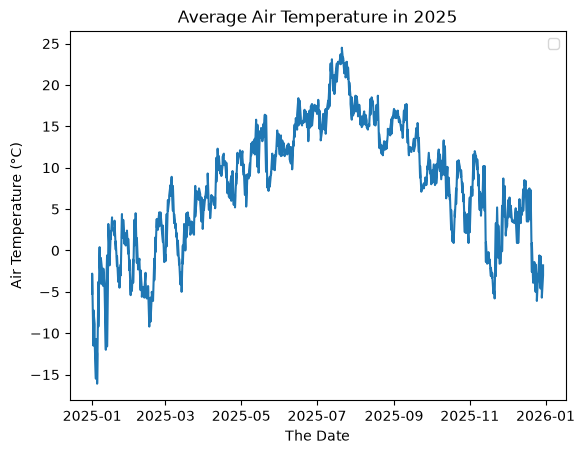

In [16]:
df['referenceTime'] = pd.to_datetime(df['referenceTime'])

plt.plot(df['referenceTime'][df['elementId'] == 'mean(air_temperature P1D)'], df['value'][df['elementId'] == 'mean(air_temperature P1D)'])
plt.title('Average Air Temperature in 2025')
plt.xlabel('The Date')
plt.ylabel('Air Temperature (°C)') 
plt.legend()
plt.show()

Summery tabbel

In [28]:
Mean_air_temperature = df[df['elementId'] == 'mean(air_temperature P1D)']['value'].mean()
Min_air_temperature = df[df['elementId'] == 'min(air_temperature P1D)']['value'].min()
Max_air_temperature = df[df['elementId'] == 'max(air_temperature P1D)']['value'].max()
Median_air_temperature = df['value'].median()

df_summery = pd.DataFrame({'Value': [Mean_air_temperature, Min_air_temperature, Max_air_temperature, Median_air_temperature]}, index=['Mean Air Temperature', 'Min Air Temperature', 'Max Air Temperature', 'Median Air Temperature'])
print(df_summery)

Mean_air_temperature = df[df['elementId'] == 'mean(air_temperature P1D)']['value'].mean()
Min_air_temperature = df[df['elementId'] == 'mean(air_temperature P1D)']['value'].min()
Max_air_temperature = df[df['elementId'] == 'mean(air_temperature P1D)']['value'].max()
Median_air_temperature = df[df['elementId'] == 'mean(air_temperature P1D)']['value'].median()

df_summery = pd.DataFrame({'Value': [Mean_air_temperature, Min_air_temperature, Max_air_temperature, Median_air_temperature]}, index=['Mean Air Temperature', 'Min Air Temperature', 'Max Air Temperature', 'Median Air Temperature'])
print(df_summery)


                            Value
Mean Air Temperature     7.903571
Min Air Temperature    -19.600000
Max Air Temperature     30.800000
Median Air Temperature   7.900000
                            Value
Mean Air Temperature     7.903571
Min Air Temperature    -16.100000
Max Air Temperature     24.500000
Median Air Temperature   8.350000
